# UniverSeg Context & Normalisation Experiment

This notebook isolates the impact of **Image Slicing/Resizing** and **Normalisation strategies** on UniverSeg's performance. It will prove why UniverSeg performed much better in the legacy setup by directly comparing the approaches on a single, raw patient volume.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import zoom

from data.DataLoader_npz import DataLoader_npz

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
universeg_path = project_root / "evaluation" / "benchmark_models" / "UniverSeg"
sys.path.insert(0, str(universeg_path))

from universeg import universeg
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = universeg(pretrained=True).to(device)
model.eval()
print("UniverSeg loaded on", device)

UniverSeg loaded on cpu


In [10]:
loader = DataLoader_npz([str(project_root / "data/test_data/FLARE_2022.npz")], val_size=0.0)

# Pick a patient with a decent sized organ/tumor
pid = list(loader.dataset.keys())[0]  # Just grab the first one
patient_data = loader.dataset[pid]
vol = patient_data["image"]
labels = patient_data["segmentations"][0]

# Let's pick label 1 (e.g. liver/tumor)
binary_mask = (labels == 1).astype(np.float32)

# Find slices with mask
z_indices = np.where(binary_mask.sum(axis=(0,1)) > 50)[0]
support_z = z_indices[len(z_indices)//2]  # Middle slice
query_z   = support_z + 10                # Offset + 10

print(f"Patient: {pid}")
print(f"Support Slice: {support_z}, Query Slice: {query_z}")


Loading NPZ dataset(s)…
Loaded 50 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\FLARE_2022.npz

Final dataset size: 50 patients.

Patient: FLARE_2022_FLARE22_Tr_0001
Support Slice: 207, Query Slice: 217


## Method 1: The "Legacy" UniverSeg Pipeline (Full Slice Resized, Per-Slice Norm)

1. Takes the entire 512x512 array.
2. Normalizes **only that 2D slice** to [0, 1].
3. Resizes down to 128x128.

In [11]:
def method1_legacy(z_idx):
    img_slice = vol[:, :, z_idx].copy()
    msk_slice = binary_mask[:, :, z_idx].copy()
    
    # 1. Per-slice Min-Max Norm
    s_min, s_max = img_slice.min(), img_slice.max()
    if s_max > s_min:
        img_slice = (img_slice - s_min) / (s_max - s_min)
    else:
        img_slice = np.zeros_like(img_slice)
        
    # 2. Resize to 128x128 using scipy (or cv2)
    img_128 = zoom(img_slice, (128/img_slice.shape[0], 128/img_slice.shape[1]), order=1)  # bilinear
    msk_128 = zoom(msk_slice, (128/msk_slice.shape[0], 128/msk_slice.shape[1]), order=0)  # nearest
    
    return img_128, msk_128

m1_supp_img, m1_supp_msk = method1_legacy(support_z)
m1_query_img, m1_query_msk = method1_legacy(query_z)

## Method 2: The "Current" Pipeline (Strict 128x128 Crop, 3D Volume Norm)

1. Normalizes the **entire 3D volume** to [0, 1].
2. Extracts a literal 128x128 crop centered strictly on the Support Mask.

In [12]:
def method2_current():
    # 1. 3D Volume Norm
    v_min, v_max = vol.min(), vol.max()
    vol_norm = (vol - v_min) / (v_max - v_min)
    
    # Extract 2D slices
    s_img = vol_norm[:, :, support_z]
    s_msk = binary_mask[:, :, support_z]
    q_img = vol_norm[:, :, query_z]
    q_msk = binary_mask[:, :, query_z]
    
    # 2. Calculate Strict 128 Crop centered on Support
    ps = 128
    nonzero = np.argwhere(s_msk > 0)
    if len(nonzero) > 0:
        min_h, min_w = nonzero.min(axis=0)
        max_h, max_w = nonzero.max(axis=0)
        
        h_center = (min_h + max_h) // 2
        w_center = (min_w + max_w) // 2
        
        sh = max(0, min(h_center - ps//2, s_img.shape[0] - ps))
        sw = max(0, min(w_center - ps//2, s_img.shape[1] - ps))
    else:
        sh, sw = 0, 0
        
    # Extract
    def crop(a):
        return a[sh:sh+ps, sw:sw+ps]
        
    return crop(s_img), crop(s_msk), crop(q_img), crop(q_msk)

m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk = method2_current()

## UniverSeg Inference and Comparison

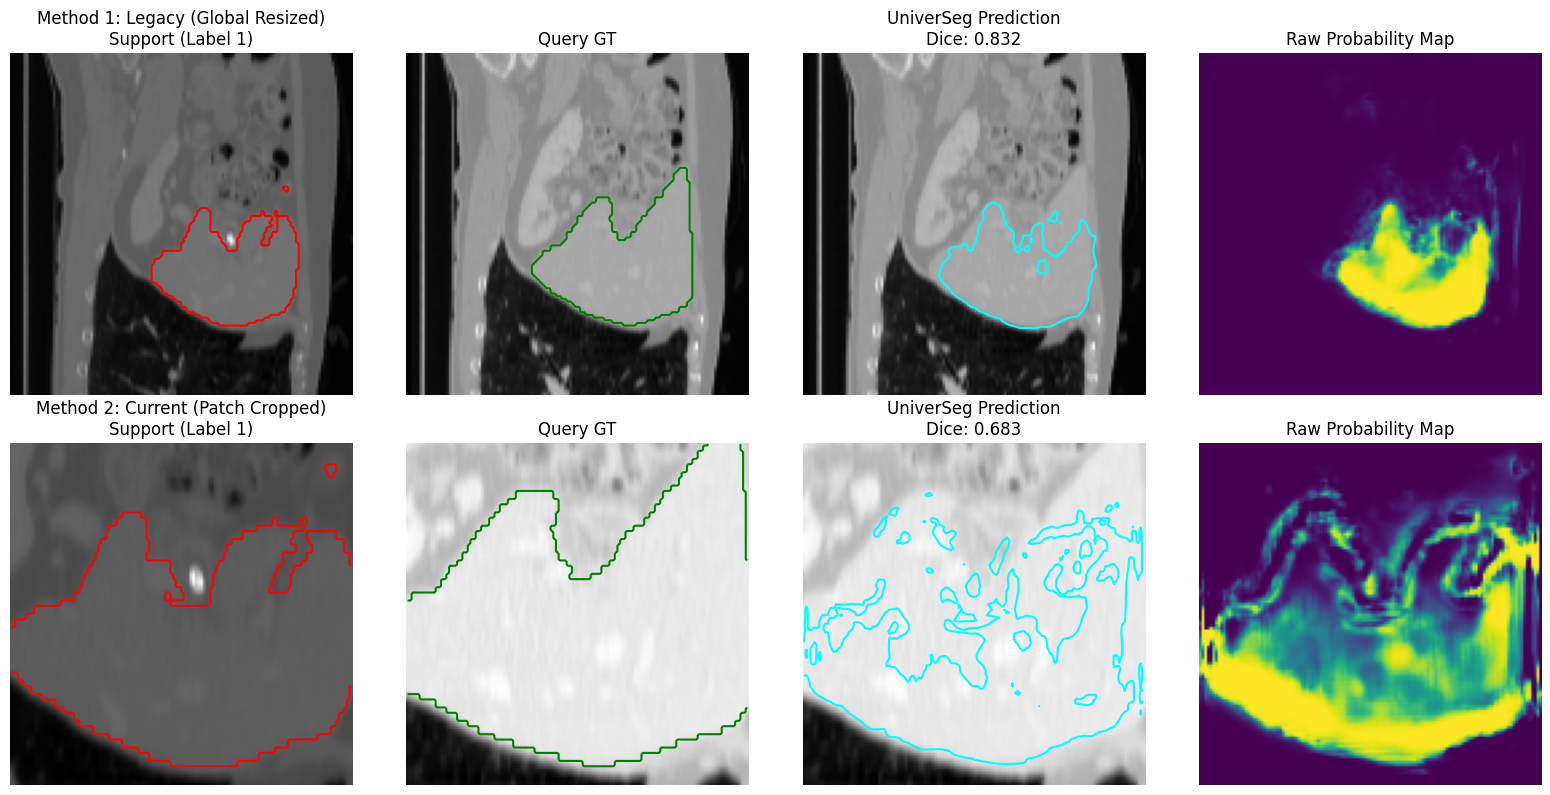

In [13]:
def dice(pred, target):
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()
    inter = (pred * target).sum()
    return (2. * inter) / (pred.sum() + target.sum() + 1e-8)

def run_universeg(s_img, s_msk, q_img, q_msk):
    # To Torch: Add Batch and Channel and Support dims
    # Supp: (B, S, C, H, W) -> (1, 1, 1, 128, 128)
    # Query: (B, C, H, W) -> (1, 1, 128, 128)
    t_s_img = torch.tensor(s_img, dtype=torch.float32, device=device).view(1, 1, 1, 128, 128)
    t_s_msk = torch.tensor(s_msk, dtype=torch.float32, device=device).view(1, 1, 1, 128, 128)
    t_q_img = torch.tensor(q_img, dtype=torch.float32, device=device).view(1, 1, 128, 128)
    t_q_msk = torch.tensor(q_msk, dtype=torch.float32, device=device).view(1, 1, 128, 128)
    
    with torch.no_grad():
        pred = model(t_q_img, t_s_img, t_s_msk)
        score = dice(torch.sigmoid(pred), t_q_msk)
        
    return torch.sigmoid(pred).squeeze().cpu().numpy(), score.item()

# Run both
m1_pred, m1_score = run_universeg(m1_supp_img, m1_supp_msk, m1_query_img, m1_query_msk)
m2_pred, m2_score = run_universeg(m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk)

# ── Visualisation ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

def show_row(row_idx, s_img, s_msk, q_img, q_msk, pred, score, title):
    axes[row_idx, 0].imshow(s_img, cmap='gray')
    axes[row_idx, 0].contour(s_msk, colors='red', levels=[0.5])
    axes[row_idx, 0].set_title(f"{title}\nSupport (Label 1)")
    
    axes[row_idx, 1].imshow(q_img, cmap='gray')
    axes[row_idx, 1].contour(q_msk, colors='green', levels=[0.5])
    axes[row_idx, 1].set_title("Query GT")
    
    axes[row_idx, 2].imshow(q_img, cmap='gray')
    axes[row_idx, 2].contour(pred, colors='cyan', levels=[0.5])
    axes[row_idx, 2].set_title(f"UniverSeg Prediction\nDice: {score:.3f}")
    
    axes[row_idx, 3].imshow(pred, cmap='viridis')
    axes[row_idx, 3].set_title("Raw Probability Map")
    
    for ax in axes[row_idx]:
        ax.axis('off')

show_row(0, m1_supp_img, m1_supp_msk, m1_query_img, m1_query_msk, m1_pred, m1_score, "Method 1: Legacy (Global Resized)")
show_row(1, m2_supp_img, m2_supp_msk, m2_query_img, m2_query_msk, m2_pred, m2_score, "Method 2: Current (Patch Cropped)")

plt.tight_layout()
plt.show()